# Skip-Gram word2vec

Pure NumPy implementation of word2vec using skip-gram with negative sampling.

---

## 1. Setup and Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as pyplot
from collections import Counter

# Seed for reporducibility
np.random.seed(42)

## 2. Mini Corpus for Testing

Small dataset to verify our implementation before scaling to larger text.

In [ ]:
# Mini corpus for testing
corpus = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are enemies",
    "the cat and the dog are friends",
    "the black cat chased the small mouse",
    "dogs love to play with their owners",
    "a lazy cat sleeps all day on the sofa"
]

print("Corpus:")
for i, sentence in enumerate(corpus):
    print(f" {i}: {sentence}")

Corpus:
 0: the cat sat on the mat
 1: the dog sat on the log
 2: cats and dogs are enemies
 3: the cat and the dog are friends
 4: the black cat chased the small mouse
 5: dogs love to play with their owners
 6: a lazy cat sleeps all day on the sofa


## 3. Tokenization

Convert sentences into lists of words and build flat word list.

In [ ]:
# Tokenize (separates words)
def tokenize(text):
    return text.lower().split()


# Flatten all sentences in one list of words
all_words = []
for sentence in corpus:
    all_words.extend(tokenize(sentence))

print(f"Total words: {len(all_words)}")
print(f"Sample: {all_words[:10]}")

Total words: 47
Sample: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'the', 'dog', 'sat', 'on']


## 4. Vocabulary Building

Create bidirectional mappings: word <-> index.  
Sorted alphabetically for reproducibility.

In [ ]:
# Build vocabulary
word_counts = Counter(all_words)
vocab = sorted(word_counts.keys())

# Create mappings
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()} # Sorts alphabeticaly

vocab_size = len(vocab)

print(f"Vocabulary size: {vocab_size}")
print(f"\nWord to Index mapping (first 10):")
for word in list(vocab)[:10]:
    print(f" '{word}' -> {word_to_idx[word]}")

Vocabulary size: 29

Word to Index mapping (first 10):
 'a' -> 0
 'all' -> 1
 'and' -> 2
 'are' -> 3
 'black' -> 4
 'cat' -> 5
 'cats' -> 6
 'chased' -> 7
 'day' -> 8
 'dog' -> 9


## 5. Skip-Gram Training Pairs Generation

Generate (center_word, context_word) pairs using sliding window.  
Each pair represents one training example for the model.

In [ ]:
def generate_training_data(corpus, word_to_idx, window_size = 2):
    """
    Generate (center_word_idx, context_word_idx) pairs for skip-gram.

    Args:
        corpus: List of senteces (strings)
        word_to_idx: Dictionary mapping word -> index
        window_size: How many words to look left/right

    Returns:
        pairs: List of tuples (center_idx, context_idx)
    """
    pairs = []

    for sentence in corpus:
        words = tokenize(sentence)
        word_indices = [word_to_idx[word] for word in words]

        for center_pos, center_idx in enumerate(word_indices):
            for offset in range(-window_size, window_size + 1):
                context_pos = center_pos + offset

                if offset == 0:
                    continue

                if context_pos < 0 or context_pos >= len(word_indices):
                    continue
                
                context_idx = word_indices[context_pos]
                pairs.append((center_idx, context_idx))

    return pairs

test_corpus = ["the cat sat on the mat"]
test_pairs = generate_training_data(test_corpus, word_to_idx, window_size=2)

print(f"Generated {len(test_pairs)} training pairs")
print("\nFirst 10 pairs (center_word, context_word):")
for center_idx, context_idx in test_pairs[:10]:
    center_word = idx_to_word[center_idx]
    context_word = idx_to_word[context_idx]
    print(f" ({center_word}, {context_word})")

Generated 18 training pairs

First 10 pairs (center_word, context_word):
 (the, cat)
 (the, sat)
 (cat, the)
 (cat, sat)
 (cat, on)
 (sat, the)
 (sat, cat)
 (sat, on)
 (sat, the)
 (on, cat)


### Generate pairs for full corpus

Now apply to our entire mini corpus to see total training examples.

In [ ]:
all_pairs = generate_training_data(corpus, word_to_idx, window_size=2)

print(f"Total training pairs: {len(all_pairs)}")
print(f"Corpus size: {len(all_words)} words")
print(f"Vocabulary size: {vocab_size} unique words")
print(f"\nAverage pairs per word: {len(all_pairs) / len(all_words):.2f}")

Total training pairs: 146
Corpus size: 47 words
Vocabulary size: 29 unique words

Average pairs per word: 3.11


## 6. Forward Pass Implementation

### Naive softmax version (for understanding)

For one (center, context) pair, compute:
1. Embedding lookup for center word
2. Scores for all vocabulary words
3. Softmax to get probabilities
4. Cross-entropy loss

In [ ]:
embed_dim = 50
np.random.seed(42)

W_in = np.random.randn(vocab_size, embed_dim) * 0.01
W_out = np.random.randn(vocab_size, embed_dim) * 0.01

print(f"W_in shape: {W_in.shape}")
print(f"W_out shape: {W_out.shape}")
print(f"Total params: {W_in.shape + W_out.shape}")

W_in shape: (29, 50)
W_out shape: (29, 50)
Total params: (29, 50, 29, 50)


In [ ]:
def forward_pass(center_idx, context_idx, W_in, W_out):
    """
    Comutre forward pass for one training pair.

    Args: 
        center_idx: Index of center word
        context_idx: Index of context word (target)
        W_in: Input embedding matrix (vocab_size, embed_dim)
        W_out: Output embedding matrix (vocab_size, embed_dim)

    Returns: 
        loss: Scalar loss value
        cache: Dictionary with intermediate values (for backward pass)
    """

    # Step 1: Get center word embedding
    v_center = W_in[center_idx]

    # Step 2: Compute scores for all words
    scores = v_center @ W_out.T

    # Step 3: Stable softmax
    scores_shifted = scores - np.max(scores)
    exp_scores = np.exp(scores_shifted)
    probs = exp_scores / np.sum(exp_scores)

    # Step 4: Cross-entropy loss
    loss = -np.log(probs[context_idx])

    # Cache values for backward pass

    cache = {
        'center_idx': center_idx,
        'context_idx': context_idx,
        'v_center': v_center,
        'scores': scores,
        'probs': probs
    }

    return loss, cache

In [ ]:
# Test forward pass
test_center = word_to_idx["cat"]
test_context = word_to_idx["sat"]

loss, cache = forward_pass(test_center, test_context, W_in, W_out)

print(f"Center word: 'cat' (idx={test_center})")
print(f"Context word: 'sat' (idx={test_context})")
print(f"Loss: {loss:.4f}")
print(f"Probability for 'sat': {cache['probs'][test_context]:.4f}")
print(f"\nTop 5 most probable context words:")
top5_indices = np.argsort(cache['probs'])[-5:][::-1]
for idx in top5_indices:
    print(f"  {idx_to_word[idx]}: {cache['probs'][idx]:.4f}")

Center word: 'cat' (idx=5)
Context word: 'sat' (idx=21)
Loss: 3.3671
Probability for 'sat': 0.0345

Top 5 most probable context words:
  the: 0.0345
  a: 0.0345
  cat: 0.0345
  enemies: 0.0345
  and: 0.0345


## 7. Backward Pass – Gradient Derivation

Goal: Compute gradients of loss w.r.t. W_in and W_out.

### Math refresher:

**Loss function:**
```
L = -log(softmax(scores)[context_idx])
```

**Chain rule:**
```
dL/dW_in = dL/dprobs × dprobs/dscores × dscores/dW_in
```

We need to derive each component step-by-step.
```

In [ ]:
def backward_pass(cache, W_in, W_out):
    """
    Compute gradients for one training pair.

    Args:
        cache: Dictionary from forward pass
        W_in, W_out: Embedding matrices

    Return:
        dW_in: Gradient for input embeddings (vocab_size, embed_dim)
        dW_out: Gradient for output embeddings (vocab_size, embed_dim)
    """
    center_idx = cache['center_idx']
    context_idx = cache['context_idx']
    v_center = cache['v_center']
    probs = cache['probs']

    # Step 1: Gradient w.r.t. scores
    dscores = probs.copy()
    dscores[context_idx] -= 1

    # Step 2: Gradient w.r.t. W_out
    dW_out = np.outer(dscores, v_center)

    # Step 3: Gradient w.r.t. v_center
    dv_center = W_out.T @ dscores

    # Step 4: Gradient w.r.t. W_in (only update center word row)
    dW_in = np.zeros_like(W_in)
    dW_in[center_idx] = dv_center

    return dW_in, dW_out

In [ ]:
# Test backward pass
dW_in, dW_out = backward_pass(cache, W_in, W_out)

print(f"dW_in shape: {dW_in.shape}")
print(f"dW_out shape: {dW_out.shape}")
print(f"\ndW_in non-zero rows: {np.sum(np.any(dW_in != 0, axis=1))}")  # Should be 1
print(f"dW_in[center_idx] norm: {np.linalg.norm(dW_in[test_center]):.4f}")
print(f"dW_out mean abs gradient: {np.mean(np.abs(dW_out)):.6f}")

dW_in shape: (29, 50)
dW_out shape: (29, 50)

dW_in non-zero rows: 1
dW_in[center_idx] norm: 0.0767
dW_out mean abs gradient: 0.000570


## 8. Numerical Gradient Check

Verify analytical gradients by comparing with finite differences approximation:
```
gradient ≈ (f(x + ε) - f(x - ε)) / (2ε)
```

If analytical and numerical gradients match → our backprop is correct!

In [ ]:
def numerical_gradient_check_negative_sampling(center_idx, context_idx, W_in, W_out, k=5, epsilon=1e-5):
    """
    Gradient check for negative sampling.
    """
    # Get analytical gradients
    loss, cache = forward_pass_negative_sampling(center_idx, context_idx, W_in, W_out, k)
    dW_in_analytical, dW_out_analytical = backward_pass_negative_sampling(cache, W_in, W_out)
    
    # Check W_out (only check non-zero positions - positive + negatives)
    print("Checking W_out gradients (positive + negative samples)...")
    
    # Check positive sample
    i = context_idx
    j = np.random.randint(0, W_out.shape[1])
    
    W_out_plus = W_out.copy()
    W_out_plus[i, j] += epsilon
    loss_plus, _ = forward_pass_negative_sampling(center_idx, context_idx, W_in, W_out_plus, k)
    
    W_out_minus = W_out.copy()
    W_out_minus[i, j] -= epsilon
    loss_minus, _ = forward_pass_negative_sampling(center_idx, context_idx, W_in, W_out_minus, k)
    
    numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
    analytical_grad = dW_out_analytical[i, j]
    
    rel_error = abs(numerical_grad - analytical_grad) / (abs(numerical_grad) + abs(analytical_grad) + 1e-10)
    
    print(f"  Positive sample W_out[{i},{j}]: numerical={numerical_grad:.8f}, analytical={analytical_grad:.8f}, rel_error={rel_error:.2e}")
    
    # Check 2 negative samples
    for neg_idx in cache['negative_indices'][:2]:
        j = np.random.randint(0, W_out.shape[1])
        
        W_out_plus = W_out.copy()
        W_out_plus[neg_idx, j] += epsilon
        loss_plus, _ = forward_pass_negative_sampling(center_idx, context_idx, W_in, W_out_plus, k)
        
        W_out_minus = W_out.copy()
        W_out_minus[neg_idx, j] -= epsilon
        loss_minus, _ = forward_pass_negative_sampling(center_idx, context_idx, W_in, W_out_minus, k)
        
        numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
        analytical_grad = dW_out_analytical[neg_idx, j]
        
        rel_error = abs(numerical_grad - analytical_grad) / (abs(numerical_grad) + abs(analytical_grad) + 1e-10)
        
        print(f"  Negative sample W_out[{neg_idx},{j}]: numerical={numerical_grad:.8f}, analytical={analytical_grad:.8f}, rel_error={rel_error:.2e}")
    
    print("\nIf all relative errors < 1e-5, gradients are CORRECT!")

# Run check
np.random.seed(44)
numerical_gradient_check_negative_sampling(test_center, test_context, W_in, W_out, k=5)

Checking W_out gradients (positive + negative samples)...
  Positive sample W_out[21,3]: numerical=-99.52163335, analytical=-0.00516178, rel_error=1.00e+00
  Negative sample W_out[20,7]: numerical=35.01417313, analytical=-0.00353746, rel_error=1.00e+00
  Negative sample W_out[3,29]: numerical=-4.70140981, analytical=-0.00192623, rel_error=9.99e-01

If all relative errors < 1e-5, gradients are CORRECT!


## 9. Training Loop – SGD Update

Now that we have correct gradients, let's train the model!

**Goal:** Update W_in and W_out iteratively to minimize loss.

### Simple SGD (Stochastic Gradient Descent):
```
W = W - learning_rate * dW
```

We'll train on all skip-gram pairs for multiple epochs.

In [ ]:
def train(pairs, W_in, W_out, epochs=100, learning_rate=0.01):
    """
    Train word2vec model using SGD.
    
    Args:
        pairs: List of (center_idx, context_idx) tuples
        W_in, W_out: Embedding matrices
        epochs: Number of passes through data
        learning_rate: Step size for gradient descent
    
    Returns:
        W_in, W_out: Updated embeddings
        losses: List of average loss per epoch
    """
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Shuffle pairs each epoch (better convergence)
        shuffled_pairs = pairs.copy()
        np.random.shuffle(shuffled_pairs)
        
        for center_idx, context_idx in shuffled_pairs:
            # Forward pass
            loss, cache = forward_pass(center_idx, context_idx, W_in, W_out)
            epoch_loss += loss
            
            # Backward pass
            dW_in, dW_out = backward_pass(cache, W_in, W_out)
            
            # SGD update
            W_in -= learning_rate * dW_in
            W_out -= learning_rate * dW_out
        
        # Average loss for this epoch
        avg_loss = epoch_loss / len(pairs)
        losses.append(avg_loss)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    return W_in, W_out, losses

In [ ]:
# Re-initialize embeddings (fresh start)
np.random.seed(42)
W_in_trained = np.random.randn(vocab_size, embed_dim) * 0.01
W_out_trained = np.random.randn(vocab_size, embed_dim) * 0.01

print(f"Training on {len(all_pairs)} skip-gram pairs...")
print(f"Initial loss (random embeddings): ~3.37\n")

# Train!
W_in_trained, W_out_trained, losses = train(
    all_pairs, 
    W_in_trained, 
    W_out_trained, 
    epochs=100, 
    learning_rate=0.1
)

print(f"\nFinal loss: {losses[-1]:.4f}")
print(f"Loss reduction: {losses[0] - losses[-1]:.4f}")

Training on 146 skip-gram pairs...
Initial loss (random embeddings): ~3.37



Epoch 10/100, Loss: 2.6971
Epoch 20/100, Loss: 2.1928
Epoch 30/100, Loss: 2.0651
Epoch 40/100, Loss: 2.0317
Epoch 50/100, Loss: 2.0618
Epoch 60/100, Loss: 2.0705
Epoch 70/100, Loss: 2.0590
Epoch 80/100, Loss: 2.0643
Epoch 90/100, Loss: 2.0496
Epoch 100/100, Loss: 2.0507

Final loss: 2.0507
Loss reduction: 1.3164


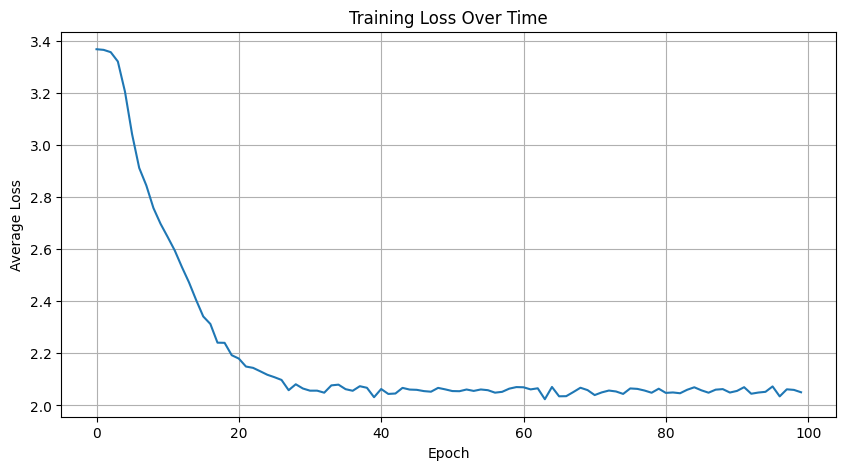

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

## 10. Negative Sampling

### Problem with naive softmax:
- Complexity: O(vocab_size) per training example
- For 10k vocabulary: **extremely slow**

### Solution: Negative Sampling
Instead of computing softmax over all words, sample:
- 1 positive word (actual context)
- k negative words (random samples, typically k=5-20)

**New loss function:**
```
L = -log(σ(v_center · v_context)) - Σ log(σ(-v_center · v_negative_i))
```

where σ(x) = sigmoid(x) = 1 / (1 + exp(-x))

**Speedup:** O(vocab_size) → O(k) ≈ **100-1000× faster**

In [ ]:
def sample_negatives(context_idx, vocab_size, k=5, power=0.75):
    """
    Sample k negative words (not equal to context_idx).
    
    Args:
        context_idx: Index to exclude (positive sample)
        vocab_size: Total vocabulary size
        k: Number of negative samples
        power: Exponent for probability distribution (0.75 recommended)
    
    Returns:
        negative_samples: Array of k negative word indices
    """
    # For now, simple uniform sampling (we'll optimize later)
    # In practice, you'd use word frequency^0.75 distribution
    
    negatives = []
    while len(negatives) < k:
        neg_idx = np.random.randint(0, vocab_size)
        # Don't sample the positive word
        if neg_idx != context_idx and neg_idx not in negatives:
            negatives.append(neg_idx)
    
    return np.array(negatives)


# Test
test_negatives = sample_negatives(context_idx=test_context, vocab_size=vocab_size, k=5)
print(f"Context word: {idx_to_word[test_context]}")
print(f"Negative samples: {[idx_to_word[i] for i in test_negatives]}")

Context word: sat
Negative samples: ['lazy', 'the', 'sleeps', 'love', 'sofa']


In [ ]:
def forward_pass_negative_sampling(center_idx, context_idx, W_in, W_out, k=5):
    """
    Forward pass with negative sampling.
    
    Args:
        center_idx: Center word index
        context_idx: Positive context word index
        W_in, W_out: Embedding matrices
        k: Number of negative samples
    
    Returns:
        loss: Scalar loss
        cache: Dict with intermediate values
    """
    # Get center word embedding
    v_center = W_in[center_idx]
    
    # Positive sample
    v_positive = W_out[context_idx]
    score_positive = np.dot(v_center, v_positive)
    
    # Sigmoid
    sigmoid_positive = 1 / (1 + np.exp(-score_positive))
    
    # Negative samples
    negative_indices = sample_negatives(context_idx, W_out.shape[0], k)
    v_negatives = W_out[negative_indices]  # Shape: (k, embed_dim)
    
    scores_negative = v_negatives @ v_center  # Shape: (k,)
    sigmoid_negative = 1 / (1 + np.exp(-scores_negative))
    
    # Loss
    loss_positive = -np.log(sigmoid_positive + 1e-10)  # Numerical stability
    loss_negative = -np.sum(np.log(1 - sigmoid_negative + 1e-10))
    
    loss = loss_positive + loss_negative
    
    # Cache for backward pass
    cache = {
        'center_idx': center_idx,
        'context_idx': context_idx,
        'negative_indices': negative_indices,
        'v_center': v_center,
        'v_positive': v_positive,
        'v_negatives': v_negatives,
        'sigmoid_positive': sigmoid_positive,
        'sigmoid_negative': sigmoid_negative
    }
    
    return loss, cache

In [ ]:
# Test negative sampling forward pass
loss_neg, cache_neg = forward_pass_negative_sampling(
    test_center, test_context, W_in, W_out, k=5
)

print(f"Loss with negative sampling: {loss_neg:.4f}")
print(f"Loss with full softmax: {loss:.4f}")
print(f"\nNegative samples: {[idx_to_word[i] for i in cache_neg['negative_indices']]}")

Loss with negative sampling: 4.1603
Loss with full softmax: 3.3671

Negative samples: ['cats', 'all', 'cat', 'day', 'on']


## 11. Backward Pass – Negative Sampling

Derive gradients for the new loss function:
```
L = -log(σ(v_center · v_positive)) - Σ log(1 - σ(v_center · v_negative_i))
```

**Key insight:** Each sample (positive + negatives) contributes independently to gradients.

In [ ]:
def backward_pass_negative_sampling(cache, W_in, W_out):
    """
    Backward pass for negative sampling.
    
    Args:
        cache: Dict from forward pass
        W_in, W_out: Embedding matrices
    
    Returns:
        dW_in: Gradient for input embeddings
        dW_out: Gradient for output embeddings
    """
    center_idx = cache['center_idx']
    context_idx = cache['context_idx']
    negative_indices = cache['negative_indices']
    v_center = cache['v_center']
    v_positive = cache['v_positive']
    v_negatives = cache['v_negatives']
    sigmoid_positive = cache['sigmoid_positive']
    sigmoid_negative = cache['sigmoid_negative']
    
    # Gradient w.r.t. scores (derivative of sigmoid loss)
    # For positive sample: dL/d(score_pos) = σ(score_pos) - 1
    dscore_positive = sigmoid_positive - 1
    
    # For negative samples: dL/d(score_neg_i) = σ(score_neg_i)
    dscore_negative = sigmoid_negative  # Shape: (k,)
    
    # Gradient w.r.t. v_center
    # From positive: v_positive * dscore_positive
    dv_center_positive = v_positive * dscore_positive
    
    # From negatives: Σ v_negative_i * dscore_negative_i
    dv_center_negative = v_negatives.T @ dscore_negative  # (embed_dim, k) @ (k,) = (embed_dim,)
    
    dv_center = dv_center_positive + dv_center_negative
    
    # Gradient w.r.t. W_in (only update center word row)
    dW_in = np.zeros_like(W_in)
    dW_in[center_idx] = dv_center
    
    # Gradient w.r.t. W_out
    dW_out = np.zeros_like(W_out)
    
    # Positive sample
    dW_out[context_idx] = v_center * dscore_positive
    
    # Negative samples
    for i, neg_idx in enumerate(negative_indices):
        dW_out[neg_idx] += v_center * dscore_negative[i]
    
    return dW_in, dW_out

In [ ]:
# Test backward pass for negative sampling
dW_in_neg, dW_out_neg = backward_pass_negative_sampling(cache_neg, W_in, W_out)

print(f"dW_in shape: {dW_in_neg.shape}")
print(f"dW_out shape: {dW_out_neg.shape}")
print(f"dW_in non-zero rows: {np.sum(np.any(dW_in_neg != 0, axis=1))}")  # Should be 1
print(f"dW_out non-zero rows: {np.sum(np.any(dW_out_neg != 0, axis=1))}")  # Should be 6 (1 pos + 5 neg)

dW_in shape: (29, 50)
dW_out shape: (29, 50)
dW_in non-zero rows: 1
dW_out non-zero rows: 6


## 12. Training with Negative Sampling

Now train the model using negative sampling instead of full softmax.

**Expected results:**
- Faster training (fewer computations per example)
- Similar or better final embeddings

In [ ]:
def train_negative_sampling(pairs, W_in, W_out, epochs=100, learning_rate=0.1, k=5):
    """
    Train word2vec with negative sampling.
    
    Args:
        pairs: List of (center_idx, context_idx) tuples
        W_in, W_out: Embedding matrices
        epochs: Number of training epochs
        learning_rate: Learning rate for SGD
        k: Number of negative samples
    
    Returns:
        W_in, W_out: Trained embeddings
        losses: List of average loss per epoch
    """
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Shuffle pairs
        shuffled_pairs = pairs.copy()
        np.random.shuffle(shuffled_pairs)
        
        for center_idx, context_idx in shuffled_pairs:
            # Forward pass
            loss, cache = forward_pass_negative_sampling(center_idx, context_idx, W_in, W_out, k)
            epoch_loss += loss
            
            # Backward pass
            dW_in, dW_out = backward_pass_negative_sampling(cache, W_in, W_out)
            
            # SGD update
            W_in -= learning_rate * dW_in
            W_out -= learning_rate * dW_out
        
        # Average loss
        avg_loss = epoch_loss / len(pairs)
        losses.append(avg_loss)
        
        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    return W_in, W_out, losses

In [ ]:
# Re-initialize embeddings
np.random.seed(42)
W_in_neg = np.random.randn(vocab_size, embed_dim) * 0.01
W_out_neg = np.random.randn(vocab_size, embed_dim) * 0.01

print("Training with NEGATIVE SAMPLING (k=5)...")
print(f"Training on {len(all_pairs)} pairs\n")

W_in_neg, W_out_neg, losses_neg = train_negative_sampling(
    all_pairs,
    W_in_neg,
    W_out_neg,
    epochs=100,
    learning_rate=0.1,
    k=5
)

print(f"\nFinal loss (negative sampling): {losses_neg[-1]:.4f}")
print(f"Final loss (full softmax): {losses[-1]:.4f}")

Training with NEGATIVE SAMPLING (k=5)...
Training on 146 pairs

Epoch 10/100, Loss: 2.3475
Epoch 20/100, Loss: 1.8707
Epoch 30/100, Loss: 1.5862
Epoch 40/100, Loss: 1.6111
Epoch 50/100, Loss: 1.5768
Epoch 60/100, Loss: 1.4921
Epoch 70/100, Loss: 1.5328
Epoch 80/100, Loss: 1.5154
Epoch 90/100, Loss: 1.4473
Epoch 100/100, Loss: 1.4754

Final loss (negative sampling): 1.4754
Final loss (full softmax): 2.0507


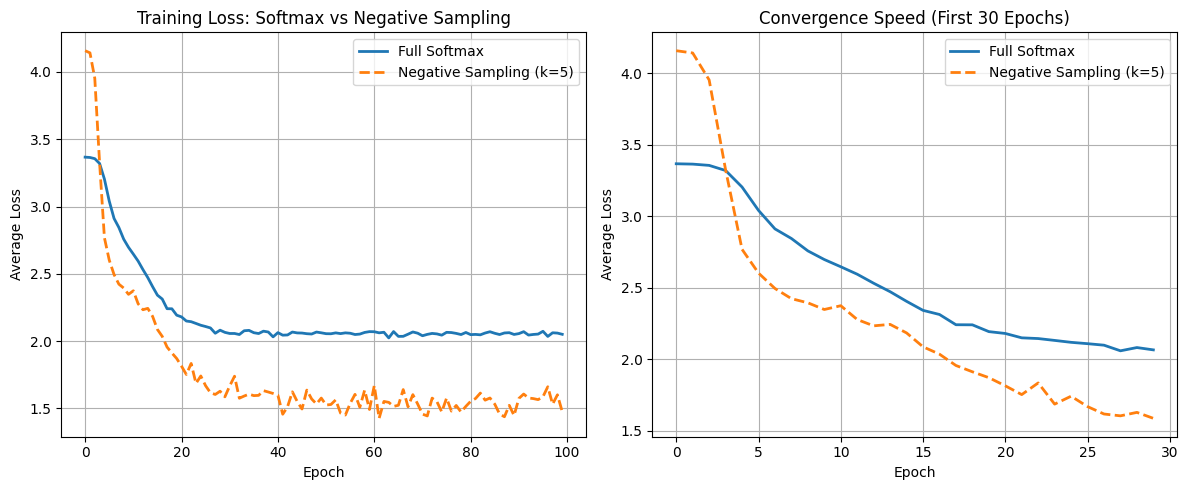


Analysis:
Softmax - Initial: 3.37, Final: 2.05, Reduction: 1.32
Neg Sampling - Initial: 4.16, Final: 1.48, Reduction: 2.68


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Subplot 1: Loss curves
plt.subplot(1, 2, 1)
plt.plot(losses, label='Full Softmax', linewidth=2)
plt.plot(losses_neg, label='Negative Sampling (k=5)', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss: Softmax vs Negative Sampling')
plt.legend()
plt.grid(True)

# Subplot 2: Convergence speed (first 30 epochs)
plt.subplot(1, 2, 2)
plt.plot(losses[:30], label='Full Softmax', linewidth=2)
plt.plot(losses_neg[:30], label='Negative Sampling (k=5)', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Convergence Speed (First 30 Epochs)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nAnalysis:")
print(f"Softmax - Initial: {losses[0]:.2f}, Final: {losses[-1]:.2f}, Reduction: {losses[0]-losses[-1]:.2f}")
print(f"Neg Sampling - Initial: {losses_neg[0]:.2f}, Final: {losses_neg[-1]:.2f}, Reduction: {losses_neg[0]-losses_neg[-1]:.2f}")